# Loss Prediction Model

## Objectives
Build a model that predicts whether a new insurance record is likely to be **loss-making** — i.e. whether `is_loss_making` will be `True` (which occurs when `loss_ratio > 1.0`, meaning costs exceeded the premium charged).

This notebook builds a reviewer-friendly baseline for predicting whether a record is likely to be **loss-making**. The emphasis is on concise exploration, leakage-aware features, and a small model comparison set that is still easy to explain.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "README.md").exists() and (PROJECT_ROOT.parent / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/DuyBui/repo/loss-pred')

# Importing Libraries

In [2]:
# Dependencies
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

In [9]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.preprocessing import OneHotEncoder

from utils.config.config import Config
from utils.ml.pickle_handler import write_to_pickle

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

In [3]:
# User-defined libraries
from utils.config.log_handler import setup_logger
from utils.config.config import Config
from utils.viz.catplot import CatPlot

In [4]:
classification_cfg = Config(single_config_path=str(PROJECT_ROOT / "conf" / "classification.toml")).get("modeling")
required_cfg_keys = {
    "target_column",
    "feature_columns",
    "categorical_features",
    "numeric_features",
    "eda_numeric_features",
    "candidate_models",
    "session_id",
    "train_size",
    "fold",
    "sort_metric",
}
missing_cfg_keys = sorted(required_cfg_keys - set(classification_cfg or {}))
if missing_cfg_keys:
    raise KeyError(f"Missing classification config keys: {missing_cfg_keys}")

TARGET = classification_cfg["target_column"]
BASE_FEATURES = classification_cfg["feature_columns"]
CATEGORICAL_FEATURES = classification_cfg["categorical_features"]
NUMERIC_FEATURES = classification_cfg["numeric_features"]
EDA_NUMERIC_FEATURES = classification_cfg["eda_numeric_features"]
ARTIFACT_PATH = PROJECT_ROOT / "app" / "artifacts" / "model.pkl"
DATA_PATH = PROJECT_ROOT / "data" / "records.csv"

In [5]:
# Logging
logger = setup_logger(level='info')

In [6]:
catpot = CatPlot()

In [7]:
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")

# Loading data

In [8]:
df = pd.read_csv(DATA_PATH)
df.head()

,record_id,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making
0,REC_0001,property,UK,healthcare,665000,15200,Nexus Broking,1.0,28.0,1.0210,True
1,REC_0002,cyber,APAC,healthcare,4126000,104900,Meridian Re,1.0,11.0,0.9007,False
2,REC_0003,cyber,LATAM,energy,906000,5900,Meridian Re,1.0,7.0,1.1317,True
3,REC_0004,marine,LATAM,transport,1008000,13200,Caldwell Specialty,1.0,1.0,0.8293,False
4,REC_0005,marine,US,manufacturing,9195000,89200,Pinnacle MGA,1.0,1.0,0.9607,True


In [10]:
df = pd.read_csv(DATA_PATH)
raw_labels = df[TARGET].astype("string").str.strip().str.lower()
df[TARGET] = (
    raw_labels
    .replace({"": pd.NA, "nan": pd.NA, "<na>": pd.NA})
    .map({"true": True, "false": False})
)
invalid_labels = raw_labels[df[TARGET].isna()].dropna().unique().tolist()
invalid_label_count = len(invalid_labels)
if invalid_label_count:
    raise ValueError(f"Unexpected labels in {TARGET}: {invalid_labels}")
if df[TARGET].isna().any():
    raise ValueError(f"Missing labels found in {TARGET}: {int(df[TARGET].isna().sum())}")
df[TARGET] = (
    df[TARGET]
    .astype(bool)
)

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns from {DATA_PATH.relative_to(PROJECT_ROOT)}")
df.head()

Loaded 504 rows and 11 columns from data\records.csv


,record_id,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making
0,REC_0001,property,UK,healthcare,665000,15200,Nexus Broking,1.0,28.0,1.0210,True
1,REC_0002,cyber,APAC,healthcare,4126000,104900,Meridian Re,1.0,11.0,0.9007,False
2,REC_0003,cyber,LATAM,energy,906000,5900,Meridian Re,1.0,7.0,1.1317,True
3,REC_0004,marine,LATAM,transport,1008000,13200,Caldwell Specialty,1.0,1.0,0.8293,False
4,REC_0005,marine,US,manufacturing,9195000,89200,Pinnacle MGA,1.0,1.0,0.9607,True


In [11]:
# unique record_id
len(df["record_id"].unique())

504

We know that `record_id` is unique for each row in the DataFrame. This means that we can use `record_id` as an index for the DataFrame, which can help with data manipulation and analysis.

In [12]:
# Set record_id as index
df.set_index("record_id", inplace=True)

# 1. Data Exploration

The goal here is to surface the specific modelling risks in the raw file: class imbalance, noisy categoricals, missingness, and leakage from `loss_ratio`.

## Missing values

In [13]:
dtype_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=False),
    }
).sort_values(["missing_count", "n_unique"], ascending=[False, False])

dtype_summary

,dtype,missing_count,missing_pct,n_unique
industry,str,21,4.17,8
years_trading,float64,20,3.97,53
prior_claims,float64,20,3.97,7
limit,int64,0,0.00,486
loss_ratio,float64,0,0.00,479
premium,int64,0,0.00,440
broker,str,0,0.00,11
territory,str,0,0.00,9
risk_type,str,0,0.00,8
is_loss_making,bool,0,0.00,2


## Class imbalance

In [14]:
class_balance = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .reset_index(name="count")
)
class_balance["pct"] = (class_balance["count"] / len(df) * 100).round(2)

class_balance

,is_loss_making,count,pct
0,False,409,81.15
1,True,95,18.85


## Numerical features

,count,mean,std,min,5%,50%,95%,max
limit,504.0,1.303741e+07,4.596345e+07,50.0000,639050.00000,4.732500e+06,4.241075e+07,999999999.0
premium,504.0,2.323171e+05,1.206484e+06,0.0000,7215.00000,6.635000e+04,6.465000e+05,22466651.0
prior_claims,484.0,1.148760e+00,1.044843e+00,0.0000,0.00000,1.000000e+00,3.000000e+00,5.0
years_trading,484.0,2.477686e+01,1.402880e+01,-3.0000,3.00000,2.350000e+01,4.700000e+01,50.0
loss_ratio,504.0,9.154196e-01,1.121218e+00,0.2475,0.45376,8.001500e-01,1.137650e+00,15.0


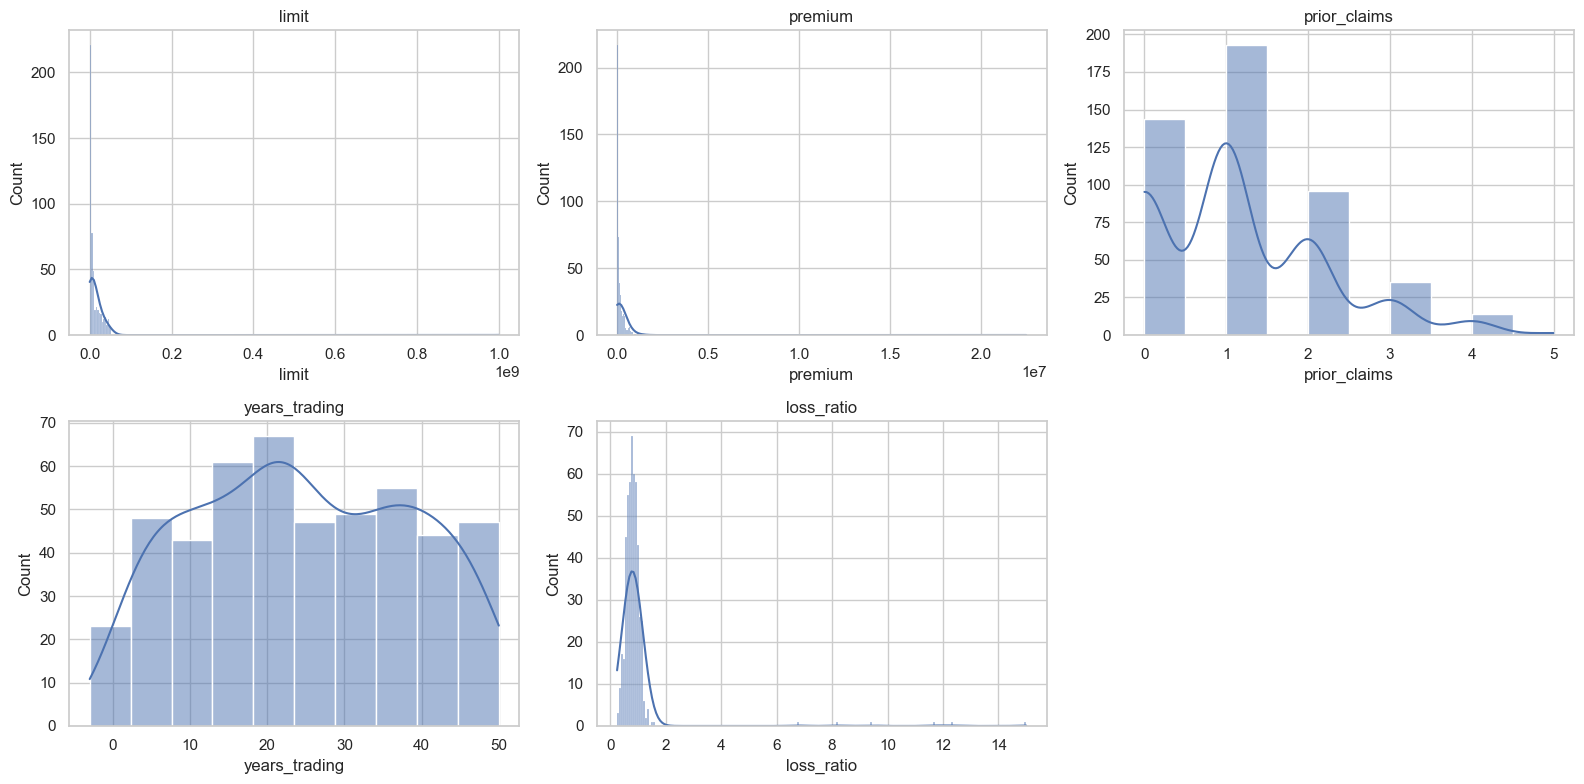

In [15]:
display(df[EDA_NUMERIC_FEATURES].describe(percentiles=[0.05, 0.5, 0.95]).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for index, column in enumerate(EDA_NUMERIC_FEATURES):
    sns.histplot(df[column], kde=True, ax=axes[index])
    axes[index].set_title(column)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

### `loss_ratio`
It was said that when `loss_ratio > 1.0`, the record is considered loss-making. We verify this by checking the distribution of `loss_ratio` for the two classes of `is_loss_making`.

In [16]:
# Bar chart to show loss_ratio > 1.0 and loss_ratio <= 1.0 for the two classes of is_loss_making. Add ratio of loss_ratio > 1.0 for each class on top of the bars.
df["loss_ratio_gt_1"] = df["loss_ratio"] > 1.0

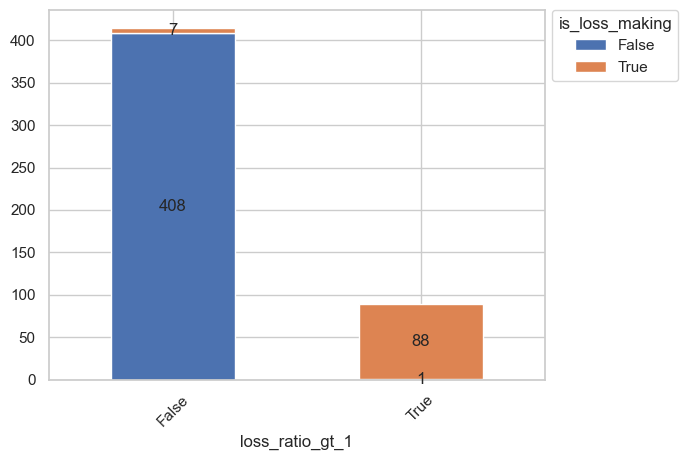

In [17]:
catpot.xtab(df, target=TARGET, cat_feature='loss_ratio_gt_1', bar_label=True)

In [18]:
# Identify the rows where loss_ratio > 1.0 but is_loss_making is False, and where loss_ratio <= 1.0 but is_loss_making is True. Display the record_id, loss_ratio, and is_loss_making for these rows.
df[(df['loss_ratio'] > 1.0) & (df['is_loss_making'] == False)]

,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making,loss_ratio_gt_1
record_id,,,,,,,,,,,
REC_0128,cyber,US,financial_services,11784000,149200,Pinnacle MGA,2.0,19.0,1.0055,False,True


In [19]:
# Identify the rows where loss_ratio <= 1.0 but is_loss_making is True, and where loss_ratio <= 1.0 but is_loss_making is True. Display the record_id, loss_ratio, and is_loss_making for these rows.
df[(df['loss_ratio'] <= 1.0) & (df['is_loss_making'] == True)].sort_values('loss_ratio', ascending=False)

,risk_type,territory,industry,limit,premium,broker,prior_claims,years_trading,loss_ratio,is_loss_making,loss_ratio_gt_1
record_id,,,,,,,,,,,
REC_0219,marine,US,healthcare,11279000,186000,Caldwell Specialty,2.0,46.0,0.9789,True,False
REC_0005,marine,US,manufacturing,9195000,89200,Pinnacle MGA,1.0,1.0,0.9607,True,False
REC_0126,marine,US,healthcare,6358000,121100,Brockton & Gray,2.0,18.0,0.9406,True,False
REC_0362,aviation,LATAM,manufacturing,2834000,99900,Caldwell Specialty,1.0,36.0,0.7323,True,False
REC_0197,liability,APAC,financial_services,1382000,7100,Nexus Broking,0.0,18.0,0.5603,True,False
REC_0488,marine,US,manufacturing,4335000,42400,Meridian Re,1.0,18.0,0.4423,True,False
REC_0183,marine,LATAM,financial_services,743000,16200,Hartwell & Sons,1.0,21.0,0.4120,True,False


In [20]:
df.columns

Index(['risk_type', 'territory', 'industry', 'limit', 'premium', 'broker',
       'prior_claims', 'years_trading', 'loss_ratio', 'is_loss_making',
       'loss_ratio_gt_1'],
      dtype='str')

It's safe to remove `loss_ratio` from the feature set, as it is a leakage feature that directly indicates whether a record is loss-making or not.

### `years_trading`
Looks like there are some `years_trading` values that are negative, which doesn't make sense. We should investigate these records further to understand why they have negative values and whether they can be corrected or should be removed from the dataset.

In [21]:
df['years_trading'].describe()

count    484.000000
mean      24.776860
std       14.028801
min       -3.000000
25%       13.000000
50%       23.500000
75%       37.000000
max       50.000000
Name: years_trading, dtype: float64

In [22]:
df[df['years_trading'] < 0][['years_trading', TARGET]]

,years_trading,is_loss_making
record_id,,
REC_0043,-3.0,False
REC_0264,-1.0,True


## Categorical features

In [23]:
for feature in CATEGORICAL_FEATURES:
    cleaned_feature = (
        df[feature]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({"": pd.NA, "nan": pd.NA, "<na>": pd.NA})
        .fillna("unknown")
    )
    summary = (
        df.assign(**{feature: cleaned_feature})
        .groupby(feature, dropna=False)[TARGET]
        .agg(["count", "mean"])
        .rename(columns={"mean": "loss_rate"})
        .sort_values(["loss_rate", "count"], ascending=[False, False])
    )
    summary["loss_rate"] = summary["loss_rate"].round(3)
    print(f"\n{feature} loss-rate summary")
    display(summary.head(15))


risk_type loss-rate summary


,count,loss_rate
risk_type,,
cyber,108,0.333
marine,111,0.189
liability,87,0.184
aviation,92,0.174
property,106,0.057



territory loss-rate summary


,count,loss_rate
territory,,
us,76,0.303
apac,102,0.186
eu,111,0.180
uk,108,0.157
latam,107,0.150



industry loss-rate summary


,count,loss_rate
industry,,
unknown,21,0.286
energy,78,0.256
healthcare,74,0.243
technology,59,0.220
manufacturing,69,0.159
financial_services,59,0.136
retail,74,0.135
transport,70,0.129



broker loss-rate summary


,count,loss_rate
broker,,
nexus broking,68,0.221
meridian re,82,0.207
pinnacle mga,61,0.197
hartwell & sons,77,0.195
caldwell specialty,72,0.181
brockton & gray,72,0.167
alston risk partners,72,0.153


## Correlations

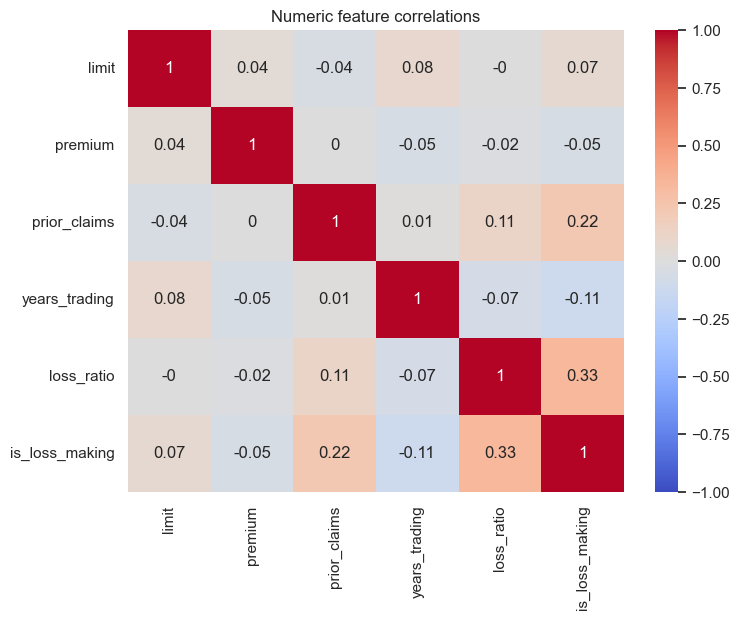

,is_loss_making
is_loss_making,1.000000
loss_ratio,0.330131
prior_claims,0.220251
limit,0.071674
premium,-0.046778
years_trading,-0.111067


In [24]:
correlation_df = df.copy()
correlation_df[TARGET] = correlation_df[TARGET].astype(int)
numeric_corr = correlation_df[EDA_NUMERIC_FEATURES + [TARGET]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr.round(2), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric feature correlations")
plt.show()

numeric_corr[[TARGET]].sort_values(by=TARGET, ascending=False)

Key findings:
- `loss_ratio` is tightly coupled to the label and must be excluded from model features to avoid leakage.
- The dataset is imbalanced, so raw accuracy alone would overstate model quality.
- Missing values are present at `years_trading`, `industry` and `claims_history`. 
- Data quality issue appears at `years_trading` with some negative values that don't make sense. 

# 2. Feature Engineering

Cleaning, imputation, and feature construction are encapsulated in a single reusable **sklearn `Pipeline`** so identical transformations apply to both the training and test sets without any test-set statistics leaking into fitted parameters.

Two aggregate features — `broker_quality_score` and `industry_risk_score` — are derived from `loss_ratio` using **out-of-fold (OOF) K-fold cross-validation** on the training set. For each fold, the group mean is computed from the *other* K-1 folds, so no row's own loss outcome contributes to its own encoded value. At test time the pipeline applies full-training group means stored during `fit`.

### Train / Test Split

The split precedes all fitting so no test-set statistics leak into pipeline parameters (medians, group means).

In [25]:
from sklearn.model_selection import train_test_split

# Exclude EDA-only helper columns before splitting
_eda_cols = [c for c in ["loss_ratio_gt_1"] if c in df.columns]
X_raw = df.drop(columns=[TARGET] + _eda_cols)
y = df[TARGET].astype(bool)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=round(1 - classification_cfg["train_size"], 2),
    random_state=classification_cfg["session_id"],
    stratify=y,
)
print(f"Train : {len(X_train_raw):,} rows  |  Test : {len(X_test_raw):,} rows")
print(f"Train positive rate : {y_train.mean():.3f}  |  Test positive rate : {y_test.mean():.3f}")

Train : 403 rows  |  Test : 101 rows
Train positive rate : 0.189  |  Test positive rate : 0.188


### Pipeline: Custom Transformers

Each transformer follows the sklearn `fit` / `transform` protocol.  `NumericImputer` stores training-set medians; `OOFGroupEncoder` stores full-training group means for test-time encoding.  All other steps are stateless.

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline


class StringCleaner(BaseEstimator, TransformerMixin):
    """Trim whitespace in all string columns and fill missing categoricals with a sentinel."""

    def __init__(self, categorical_cols, fill_value="Unknown"):
        self.categorical_cols = categorical_cols
        self.fill_value = fill_value

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in X.select_dtypes(include=["object", "string"]).columns:
            X[col] = X[col].astype("string").str.strip()
        for col in self.categorical_cols:
            if col in X.columns:
                X[col] = (
                    X[col]
                    .astype("string")
                    .str.strip()
                    .replace({"": pd.NA, "nan": pd.NA, "<na>": pd.NA})
                    .fillna(self.fill_value)
                )
        return X


class NumericCoercer(BaseEstimator, TransformerMixin):
    """Coerce specified columns to numeric; non-parseable values become NaN."""

    def __init__(self, numeric_cols):
        self.numeric_cols = numeric_cols

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in self.numeric_cols:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
        return X


class MissingFlagger(BaseEstimator, TransformerMixin):
    """Add binary flag columns recording missingness and known invalid values before imputation."""

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X, y=None):
        X = X.copy()
        if "prior_claims" in X.columns:
            X["prior_claims_missing"] = X["prior_claims"].isna().astype(int)
        if "years_trading" in X.columns:
            X["years_trading_invalid"] = (X["years_trading"] < 0).astype(int)
            X["years_trading_missing"] = X["years_trading"].isna().astype(int)
        return X


class NumericImputer(BaseEstimator, TransformerMixin):
    """
    Impute numeric columns using training-set statistics learned in fit().

    - prior_claims  : fill NaN with 0, clip negatives to 0.
    - years_trading : cap negatives at 0, fill NaN with training median.
    - premium/limit : fill NaN with training median; floor only — large values
                      are valid exposures and must not be upper-capped.
    """

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        self.years_trading_median_ = (
            X["years_trading"].clip(lower=0).median() if "years_trading" in X.columns else 0.0
        )
        self.premium_median_ = X["premium"].median() if "premium" in X.columns else 0.0
        self.limit_median_ = X["limit"].median() if "limit" in X.columns else 1.0
        return self

    def transform(self, X, y=None):
        X = X.copy()
        if "prior_claims" in X.columns:
            X["prior_claims"] = X["prior_claims"].fillna(0).clip(lower=0)
        if "years_trading" in X.columns:
            X["years_trading"] = X["years_trading"].clip(lower=0).fillna(self.years_trading_median_)
        if "premium" in X.columns:
            X["premium"] = X["premium"].fillna(self.premium_median_).clip(lower=0)
        if "limit" in X.columns:
            X["limit"] = X["limit"].fillna(self.limit_median_).clip(lower=1)
        return X


class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Create rate-style, log-scale, and ordinal features from cleaned columns."""

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X["premium_to_limit"] = X["premium"] / X["limit"]
        X["log_limit"] = np.log1p(X["limit"])
        X["log_premium"] = np.log1p(X["premium"])
        X["claims_per_year"] = X["prior_claims"] / X["years_trading"].clip(lower=1)
        X["experience_band"] = pd.cut(
            X["years_trading"],
            bins=[-0.1, 3, 10, 25, float("inf")],
            labels=["startup", "early", "established", "mature"],
        ).astype(str)
        return X


class OOFGroupEncoder(BaseEstimator, TransformerMixin):
    """
    Leakage-safe group-mean encoder driven by loss_ratio.

    fit_transform (training):
        Each row's score is the mean loss_ratio of its group computed from the
        *other* K-1 folds, so a row's own outcome never inflates its own score.

    transform (test / inference):
        Full-training group means (stored in fit) are applied directly.
        Groups unseen during training fall back to the global training mean.
    """

    def __init__(
        self,
        group_col,
        score_col,
        loss_ratio_col="loss_ratio",
        n_splits=5,
        random_state=42,
    ):
        self.group_col = group_col
        self.score_col = score_col
        self.loss_ratio_col = loss_ratio_col
        self.n_splits = n_splits
        self.random_state = random_state

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        self.global_mean_ = X[self.loss_ratio_col].mean()
        self.group_means_ = X.groupby(self.group_col)[self.loss_ratio_col].mean()
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X[self.score_col] = X[self.group_col].map(self.group_means_).fillna(self.global_mean_)
        return X

    def fit_transform(self, X, y=None, **fit_params):
        self.fit(X, y)
        X = X.copy()
        oof = pd.Series(np.nan, index=X.index)
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for fold_train_idx, fold_val_idx in kf.split(X):
            fold_train = X.iloc[fold_train_idx]
            fold_val = X.iloc[fold_val_idx]
            fold_means = fold_train.groupby(self.group_col)[self.loss_ratio_col].mean()
            fold_global = fold_train[self.loss_ratio_col].mean()
            oof.iloc[fold_val_idx] = fold_val[self.group_col].map(fold_means).fillna(fold_global)
        X[self.score_col] = oof
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """
    Encode categorical features for model consumption.

    - Nominal columns (risk_type, territory): OneHotEncoding with drop='first'
      to avoid perfect multicollinearity. Unseen categories at test time produce
      an all-zero row via handle_unknown='ignore'.
    - Ordered column (experience_band): mapped to integer ranks
      (startup=0, early=1, established=2, mature=3) so both tree-based and
      linear models can exploit the ordinal signal without dummy explosion.
    """

    def __init__(self, nominal_cols, ordinal_col_map):
        self.nominal_cols = nominal_cols          # list of column names for OHE
        self.ordinal_col_map = ordinal_col_map    # {col: [ordered categories low→high]}

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        try:
            self.ohe_ = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
            self.ohe_.fit(X[self.nominal_cols].astype(str))
        except TypeError:
            # sklearn < 1.2 uses sparse= instead of sparse_output=
            self.ohe_ = OneHotEncoder(drop="first", sparse=False, handle_unknown="ignore")
            self.ohe_.fit(X[self.nominal_cols].astype(str))
        self.ordinal_maps_ = {
            col: {cat: i for i, cat in enumerate(cats)}
            for col, cats in self.ordinal_col_map.items()
        }
        return self

    def transform(self, X, y=None):
        X = X.copy()
        # OneHot-encode nominal columns, replacing originals with expanded dummies
        ohe_values = self.ohe_.transform(X[self.nominal_cols].astype(str))
        ohe_col_names = self.ohe_.get_feature_names_out(self.nominal_cols)
        ohe_df = pd.DataFrame(ohe_values, columns=ohe_col_names, index=X.index)
        X = X.drop(columns=self.nominal_cols)
        X = pd.concat([X, ohe_df], axis=1)
        # Ordinal-encode ordered columns in place
        for col, mapping in self.ordinal_maps_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping).fillna(-1).astype(int)
        return X


class LeakageDropper(BaseEstimator, TransformerMixin):
    """Remove columns that would leak the target into the feature matrix."""

    def __init__(self, cols_to_drop=("loss_ratio",)):
        self.cols_to_drop = list(cols_to_drop)

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X, y=None):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

### Pipeline Composition

Steps run sequentially: string cleaning → numeric coercion → missingness flags → imputation → derived features → OOF group scores → leakage column removal.

In [27]:
feature_pipeline = Pipeline([
    ("clean_strings",   StringCleaner(categorical_cols=CATEGORICAL_FEATURES)),
    ("coerce_numerics", NumericCoercer(numeric_cols=NUMERIC_FEATURES + ["loss_ratio"])),
    ("flag_missing",    MissingFlagger()),
    ("impute",          NumericImputer()),
    ("engineer",        FeatureEngineer()),
    ("broker_score",    OOFGroupEncoder(
        group_col="broker",
        score_col="broker_quality_score",
        n_splits=classification_cfg["fold"],
        random_state=classification_cfg["session_id"],
    )),
    ("industry_score",  OOFGroupEncoder(
        group_col="industry",
        score_col="industry_risk_score",
        n_splits=classification_cfg["fold"],
        random_state=classification_cfg["session_id"],
    )),
    ("encode_cats",     CategoricalEncoder(
        nominal_cols=["risk_type", "territory"],
        ordinal_col_map={"experience_band": ["startup", "early", "established", "mature"]},
    )),
    ("drop_leakage",    LeakageDropper(cols_to_drop=["loss_ratio"])),
])

print("Pipeline steps:")
for name, step in feature_pipeline.steps:
    print(f"  {name}: {type(step).__name__}")

Pipeline steps:
  clean_strings: StringCleaner
  coerce_numerics: NumericCoercer
  flag_missing: MissingFlagger
  impute: NumericImputer
  engineer: FeatureEngineer
  broker_score: OOFGroupEncoder
  industry_score: OOFGroupEncoder
  encode_cats: CategoricalEncoder
  drop_leakage: LeakageDropper


In [28]:
# Fit on training data — OOF cross-validation for group scores
X_train = feature_pipeline.fit_transform(X_train_raw)
# Apply stored parameters to test data
X_test = feature_pipeline.transform(X_test_raw)

# Drop raw inputs that have been superseded by engineered features.
# risk_type and territory are now OHE-expanded by the pipeline so they
# appear as risk_type_* / territory_* columns rather than the original strings.
_drop_raw = ["limit", "premium", "prior_claims", "years_trading", "broker", "industry"]
model_features = [col for col in X_train.columns if col not in _drop_raw]

# Build model DataFrames — test set is a true holdout, never seen during training
model_df = X_train[model_features].copy()
model_df[TARGET] = y_train

test_model_df = X_test[model_features].copy()
test_model_df[TARGET] = y_test

print(f"Training set : {model_df.shape[0]:,} rows × {len(model_features)} features")
print(f"Test set     : {test_model_df.shape[0]:,} rows × {len(model_features)} features")
print(f"\nModel features ({len(model_features)}): {model_features}")
print(
    f"\nOOF broker_quality_score  — mean: {X_train['broker_quality_score'].mean():.4f},"
    f" std: {X_train['broker_quality_score'].std():.4f}"
)
print(
    f"OOF industry_risk_score   — mean: {X_train['industry_risk_score'].mean():.4f},"
    f" std: {X_train['industry_risk_score'].std():.4f}"
)
display(model_df.head())

Training set : 403 rows × 21 features
Test set     : 101 rows × 21 features

Model features (21): ['prior_claims_missing', 'years_trading_invalid', 'years_trading_missing', 'premium_to_limit', 'log_limit', 'log_premium', 'claims_per_year', 'experience_band', 'broker_quality_score', 'industry_risk_score', 'risk_type_Marine', 'risk_type_Property', 'risk_type_aviation', 'risk_type_cyber', 'risk_type_liability', 'risk_type_marine', 'risk_type_property', 'territory_EU', 'territory_LATAM', 'territory_UK', 'territory_US']

OOF broker_quality_score  — mean: 0.9218, std: 0.1543
OOF industry_risk_score   — mean: 0.9160, std: 0.1529


,prior_claims_missing,years_trading_invalid,years_trading_missing,premium_to_limit,log_limit,log_premium,claims_per_year,experience_band,broker_quality_score,industry_risk_score,...,risk_type_aviation,risk_type_cyber,risk_type_liability,risk_type_marine,risk_type_property,territory_EU,territory_LATAM,territory_UK,territory_US,is_loss_making
record_id,,,,,,,,,,,,,,,,,,,,,
REC_0342,0,0,0,0.010551,16.856981,12.305470,0.000000,3,0.862241,0.732052,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False
REC_0146,0,0,0,0.009145,14.603059,9.908525,0.096774,3,0.995567,1.227598,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False
REC_0492,0,0,0,0.019624,16.908778,12.977802,0.000000,3,1.075043,1.062661,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,False
REC_0359,0,0,0,0.016274,16.300501,12.182297,0.000000,3,1.301576,0.724142,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False
REC_0113,0,0,0,0.026752,15.976071,12.354928,0.000000,2,0.769878,1.045416,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,False


# 3. Model Training

Three candidates are trained and compared: **LightGBM**, **Random Forest**, and **Logistic Regression**.

**Data splits used in this section:**
- `model_df` (training set) is split further into a **train** subset (model fitting) and a **validation** subset (AUC comparison during selection). This split is internal to section 3 and does not affect the feature pipeline.
- `test_model_df` (held-out test set) is **not touched** during training or model selection. It is used only after the best model has been re-fitted to compute final AUC.

In [35]:
from sklearn.model_selection import train_test_split as _tts

X_model = model_df[model_features]
y_model = model_df[TARGET].astype(bool)
X_test_features = test_model_df[model_features]
y_test_features = test_model_df[TARGET].astype(bool)

X_tr, X_val, y_tr, y_val = _tts(
    X_model,
    y_model,
    test_size=round(1 - classification_cfg["train_size"], 2),
    random_state=classification_cfg["session_id"],
    stratify=y_model,
)

print(f"Train      : {len(X_tr):,} rows  (positive rate: {y_tr.mean():.3f})")
print(f"Validation : {len(X_val):,} rows  (positive rate: {y_val.mean():.3f})")
print(f"Test       : {len(X_test_features):,} rows  (positive rate: {y_test_features.mean():.3f})")

Train      : 322 rows  (positive rate: 0.189)
Validation : 81 rows  (positive rate: 0.185)
Test       : 101 rows  (positive rate: 0.188)


In [36]:
import lightgbm as lgb

# --- 1. Class-imbalance weight ---
_n_neg = int((y_tr == False).sum())
_n_pos = int((y_tr == True).sum())
_scale_pos_weight = _n_neg / _n_pos
print(f"scale_pos_weight: {_scale_pos_weight:.2f}  (neg={_n_neg}, pos={_n_pos})")

# --- 2. Candidates ---
# LightGBM: imbalance weight + conservative tree shape + early stopping
# RF / LR: unchanged
CANDIDATE_MODELS = {
    "lightgbm": LGBMClassifier(
        n_estimators=500,           # upper bound; early stopping picks the right number
        learning_rate=0.05,
        num_leaves=15,              # default 31 → overfits on small data
        min_child_samples=30,       # default 20 → raised to force more conservative splits
        reg_alpha=0.1,
        reg_lambda=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=_scale_pos_weight,
        random_state=classification_cfg["session_id"],
        n_jobs=1,
        verbose=-1,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=classification_cfg["session_id"],
        n_jobs=1,
    ),
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        random_state=classification_cfg["session_id"],
        n_jobs=1,
    ),
}

# Early-stopping callbacks — only used for LightGBM
_lgb_callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=0),
]

fitted_models = {}
results = []
for name, clf in CANDIDATE_MODELS.items():
    if name == "lightgbm":
        clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=_lgb_callbacks)
        print(f"  LightGBM best iteration: {clf.best_iteration_}")
    else:
        clf.fit(X_tr, y_tr)

    val_auc  = roc_auc_score(y_val,          clf.predict_proba(X_val)[:, 1])
    test_auc = roc_auc_score(y_test_features, clf.predict_proba(X_test_features)[:, 1])
    fitted_models[name] = clf
    results.append({"model": name, "val_auc": round(val_auc, 4), "test_auc": round(test_auc, 4)})

results_df = (
    pd.DataFrame(results)
    .sort_values("test_auc", ascending=False)
    .reset_index(drop=True)
)
display(results_df)

scale_pos_weight: 4.28  (neg=261, pos=61)
  LightGBM best iteration: 1


,model,val_auc,test_auc
0,logistic_regression,0.5354,0.6675
1,random_forest,0.6066,0.6605
2,lightgbm,0.5742,0.6146


The comparison set is intentionally narrow: logistic regression and a single decision tree anchor interpretability, while random forest, extra trees, and LightGBM test whether modestly more complex tree ensembles earn their keep.

In [37]:
best_model_name = results_df.iloc[0]["model"]
print(f"Best model : {best_model_name}  (test AUC: {results_df.iloc[0]['test_auc']:.4f})")

# Clone to get a fresh (unfitted) copy, then re-fit on the full training set
# (train + validation combined) so no validation rows are withheld
best_model = clone(fitted_models[best_model_name])
best_model.fit(X_model, y_model)
print(f"Re-fitted on full training set ({X_model.shape[0]:,} rows)")

Best model : logistic_regression  (test AUC: 0.6675)
Re-fitted on full training set (403 rows)


Final model : logistic_regression
              precision    recall  f1-score   support

       False      0.812     0.951     0.876        82
        True      0.200     0.053     0.083        19

    accuracy                          0.782       101
   macro avg      0.506     0.502     0.480       101
weighted avg      0.697     0.782     0.727       101

Test ROC-AUC : 0.6579


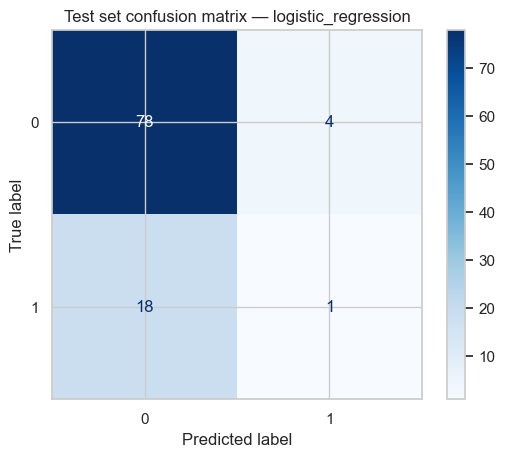

In [38]:
# Final evaluation on the held-out test set — unseen during all training and selection
y_test_prob = best_model.predict_proba(X_test_features)[:, 1]
y_test_pred = best_model.predict(X_test_features)

print(f"Final model : {best_model_name}")
print(classification_report(y_test_features, y_test_pred, digits=3))
print(f"Test ROC-AUC : {roc_auc_score(y_test_features, y_test_prob):.4f}")

cm = confusion_matrix(y_test_features, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title(f"Test set confusion matrix — {best_model_name}")
plt.show()

## Feature Importance

In [39]:
if hasattr(best_model, "feature_importances_"):
    importance_df = (
        pd.DataFrame({"feature": model_features, "importance": best_model.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    display(importance_df.head(15))
    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df.head(15), x="importance", y="feature", orient="h")
    plt.title(f"Top feature importances — {best_model_name}")
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    coef_df = (
        pd.DataFrame({"feature": model_features, "coefficient": best_model.coef_[0]})
        .sort_values("coefficient", key=abs, ascending=False)
        .reset_index(drop=True)
    )
    display(coef_df.head(15))
else:
    print("Feature importances not available for this estimator.")

,feature,coefficient
0,claims_per_year,1.021960
1,years_trading_missing,-1.017676
2,risk_type_cyber,0.961049
3,risk_type_property,-0.932442
4,prior_claims_missing,-0.650234
5,industry_risk_score,0.448797
6,log_premium,-0.444774
7,territory_US,0.403323
8,risk_type_Property,-0.385819
9,territory_UK,-0.371312


This is a reviewer-support model, not an autonomous decision system. The training data is small and intentionally noisy, so the score should be treated as one input into triage rather than a final answer.

# 4. Save Model Artifact

The saved artifact includes the finalized model plus the feature metadata and config needed to reproduce the modelling context downstream.

In [40]:
PIPELINE_PATH = PROJECT_ROOT / "app" / "artifacts" / "feature_pipeline.pkl"

artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_columns": model_features,
    "config": classification_cfg,
    "target_column": TARGET,
}

write_to_pickle(artifact, str(ARTIFACT_PATH))
print(f"Model artifact saved to    {ARTIFACT_PATH}")

write_to_pickle(feature_pipeline, str(PIPELINE_PATH))
print(f"Pipeline artifact saved to {PIPELINE_PATH}")

Model artifact saved to    C:\Users\DuyBui\repo\loss-pred\app\artifacts\model.pkl
Pipeline artifact saved to C:\Users\DuyBui\repo\loss-pred\app\artifacts\feature_pipeline.pkl


In [41]:
for path in [ARTIFACT_PATH, PIPELINE_PATH]:
    exists = path.exists()
    size = path.stat().st_size if exists else 0
    print(f"{path.name:30s}  exists={exists}  size={size:,} bytes")

model.pkl                       exists=True  size=2,349 bytes
feature_pipeline.pkl            exists=True  size=4,004 bytes
